# Домашнее задание: Multi-Branch MLP для Wine Quality

**Цель**: Реализовать multi-branch модель и добиться F1 score ≥ 40%

**Задачи**:
1. Реализовать три типа блоков: Bottleneck, Inverted Bottleneck, Regular
2. Создать Multi-Branch архитектуру
3. Использовать weighted loss для борьбы с дисбалансом классов
4. Подобрать оптимальные гиперпараметры (глубина, ширина, lr, оптимизатор)

In [1]:
import os

import pylab as pl
from lightning_fabric.loggers import CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
import sys
sys.path.append('../../lesson3/seminar')
from lesson3.seminar.wine_quality_data import WineQualityDataModule
from lesson3.seminar.lightning_module import BaseLightningModule
from lesson3.seminar.utils import set_seed
from pytorch_lightning import Trainer
import torch
import torch.nn as nn
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
set_seed(42)
import torch
print(torch.cuda.is_available())
max_epochs = 20
torch.set_float32_matmul_precision("medium")

True


## 1. Загрузка и анализ данных

Загрузим Wine Quality датасет и проанализируем распределение классов.

In [2]:
# Загружаем данные
dm = WineQualityDataModule(batch_size=128)
dm.setup()

print(f'Train samples: {len(dm.train_dataset)}')
print(f'Val samples: {len(dm.val_dataset)}')
print(f'Input dim: {dm.input_dim}')
print(f'Num classes: {dm.n_classes}')

Train samples: 1279
Val samples: 320
Input dim: 11
Num classes: 6


### 1.1. Анализ дисбаланса классов

Проанализируйте распределение классов и вычислите веса для weighted loss.

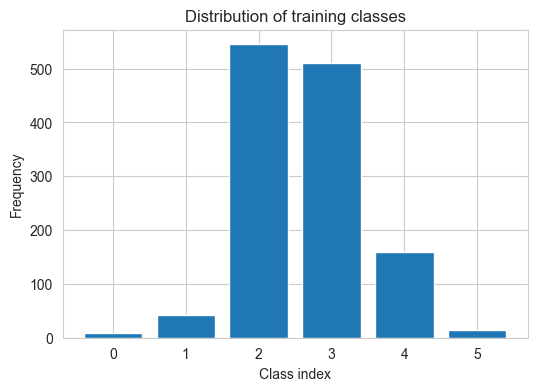

Class weights: [26.64583333  5.07539683  0.3911315   0.41797386  1.34067086 14.21111111]


In [3]:

train_labels = []
for i in range(len(dm.train_dataset)):
    _, yi = dm.train_dataset[i]
    train_labels.append(int(yi))
train_labels = np.array(train_labels)


plt.figure(figsize=(6, 4))
plt.hist(train_labels, bins=np.arange(dm.n_classes + 1) - 0.5, rwidth=0.8)
plt.xticks(range(dm.n_classes))
plt.xlabel('Class index')
plt.ylabel('Frequency')
plt.title('Distribution of training classes')
plt.show()


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(dm.n_classes),
    y=train_labels
)

print(f'Class weights: {class_weights}')


## 2. Реализация блоков

Реализуйте три типа блоков:
- **Bottleneck**: dim → dim//4 → dim (сужение)
- **Inverted Bottleneck**: dim → dim*4 → dim (расширение)
- **Regular**: dim → hidden_dim → dim (обычный)

In [4]:
from abc import ABC, abstractmethod

class BaseMLPBlock(nn.Module, ABC):
    """Базовый класс для MLP блока"""
    def __init__(self, dim, activation='gelu', dropout=0.0):
        super().__init__()
        self.dim = dim
        self.activation = {'relu': nn.ReLU(), 'gelu': nn.GELU(), 'swish': nn.SiLU()}.get(activation, nn.GELU())
        self.dropout = nn.Dropout(dropout) if dropout > 0 else None
    
    @abstractmethod
    def forward(self, x):
        pass

class BottleneckBlock(BaseMLPBlock):
    """
    Bottleneck блок: dim → dim//4 → dim
    
    Сужает размерность в 4 раза, затем восстанавливает.
    Использует residual connection для стабильного обучения.
    """
    def __init__(self, dim, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Bottleneck dimension (сужение в 4 раза)
        self.bottleneck_dim = max(dim // 4, 1)
        
        # Линейные слои: dim → bottleneck_dim → dim
        self.fc1 = nn.Linear(self.dim, self.bottleneck_dim)
        self.fc2 = nn.Linear(self.bottleneck_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Bottleneck pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        
        # Residual connection
        return out + identity

class InvertedBottleneckBlock(BaseMLPBlock):
    """
    Inverted Bottleneck блок: dim → dim*4 → dim
    
    Расширяет размерность в 4 раза, затем сжимает обратно.
    Использует residual connection для стабильного обучения.
    """
    def __init__(self, dim, expansion_factor=4, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Expanded dimension (расширение в 4 раза)
        self.expanded_dim = dim * expansion_factor
        
        # Линейные слои: dim → expanded_dim → dim
        self.fc1 = nn.Linear(self.dim, self.expanded_dim)
        self.fc2 = nn.Linear(self.expanded_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Inverted bottleneck pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        
        # Residual connection
        return out + identity

class RegularBlock(BaseMLPBlock):
    """
    Regular блок: dim → hidden_dim → dim
    
    Обычный двухслойный MLP с residual connection.
    hidden_dim по умолчанию равен dim * 2.
    """
    def __init__(self, dim, hidden_dim=None, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Hidden dimension (по умолчанию в 2 раза больше)
        self.hidden_dim = hidden_dim if hidden_dim else dim * 2

        # Линейные слои: dim → hidden_dim → dim
        self.fc1 = nn.Linear(self.dim, self.hidden_dim)
        self.fc2 = nn.Linear(self.hidden_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Regular pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        
        # Residual connection
        return out + identity

# Тестируем блоки
print('✓ Блоки успешно определены!')
print()

# Проверим размерности
test_x = torch.randn(4, 64)
print('Тестирование блоков с размерностью 64:')
print(f'  Input shape: {test_x.shape}')

bottleneck = BottleneckBlock(64)
print(f'  BottleneckBlock output: {bottleneck(test_x).shape}')

inverted = InvertedBottleneckBlock(64)
print(f'  InvertedBottleneckBlock output: {inverted(test_x).shape}')

regular = RegularBlock(64)
print(f'  RegularBlock output: {regular(test_x).shape}')

# Подсчитаем параметры
print()
print('Количество параметров:')
print(f'  BottleneckBlock: {sum(p.numel() for p in bottleneck.parameters()):,}')
print(f'  InvertedBottleneckBlock: {sum(p.numel() for p in inverted.parameters()):,}')
print(f'  RegularBlock: {sum(p.numel() for p in regular.parameters()):,}')

✓ Блоки успешно определены!

Тестирование блоков с размерностью 64:
  Input shape: torch.Size([4, 64])
  BottleneckBlock output: torch.Size([4, 64])
  InvertedBottleneckBlock output: torch.Size([4, 64])
  RegularBlock output: torch.Size([4, 64])

Количество параметров:
  BottleneckBlock: 2,128
  InvertedBottleneckBlock: 33,088
  RegularBlock: 16,576


## 3. Multi-Branch модель

Реализуйте модель с тремя параллельными ветками.

**Архитектура**:
```
         Input
           |
      projection
           |
      ┌────┼────┐
      │    │    │
  Bottleneck  Inverted  Regular
   Branch      Branch    Branch
      │    │    │
      └────┼────┘
           |
      Concatenate/Sum
           |
      projection
           |
        Output
```

In [5]:
class MultiBranchMLP(nn.Module):
    """
    Multi-Branch MLP с тремя параллельными ветками.
    
    Args:
        input_dim: размерность входа
        hidden_dim: размерность скрытых слоев
        output_dim: размерность выхода (число классов)
        num_blocks: количество блоков в каждой ветке
        dropout: вероятность dropout
        combine_mode: способ объединения веток ('concat' или 'sum')
    """
    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        num_blocks=4,
        dropout=0.1,
        combine_mode='concat',
        activation='gelu'
    ):
        super().__init__()
        self.output_dim = output_dim
        self.combine_mode = combine_mode

        # Входная проекция
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        # Три ветви: Bottleneck, Inverted Bottleneck и Regular
        self.bottleneck_branch = nn.ModuleList([
            BottleneckBlock(hidden_dim, dropout=dropout,activation=activation) for _ in range(num_blocks)
        ])
        self.inverted_branch = nn.ModuleList([
            InvertedBottleneckBlock(hidden_dim, dropout=dropout,activation=activation) for _ in range(num_blocks)
        ])
        self.regular_branch = nn.ModuleList([
            RegularBlock(hidden_dim, dropout=dropout,activation=activation) for _ in range(num_blocks)
        ])


        class ResidualMLPBlock(nn.Module):
            def __init__(self, dim: int, dropout: float = 0.1):
                super().__init__()
                self.block = nn.Sequential(
                nn.Linear(dim, dim),
                nn.BatchNorm1d(dim),
                nn.ReLU(),
                nn.Dropout(dropout)
                )


            def forward(self, x):
                return x + self.block(x)
        self.shared_blocks = nn.Sequential(*[ResidualMLPBlock(hidden_dim, dropout=0.1) for _ in range(num_blocks)]
)

        # Выходная проекция.  Для concat вход равен hidden_dim*3, для sum — hidden_dim
        combined_dim = hidden_dim * 3 if combine_mode == 'concat' else hidden_dim
        self.output_proj = nn.Linear(combined_dim, output_dim)

    def forward(self, x):
        # Входная проекция
        x = self.input_proj(x)
        # Bottleneck ветка
        out_bottleneck = x
        for block in self.bottleneck_branch:
            out_bottleneck = block(out_bottleneck)
        # Inverted Bottleneck ветка
        out_inverted = x
        for block in self.inverted_branch:
            out_inverted = block(out_inverted)
        # Regular ветка
        out_regular = x
        for block in self.regular_branch:
            out_regular = block(out_regular)
        # Объединение результатов
        if self.combine_mode == 'concat':
            out = torch.cat([out_bottleneck, out_inverted, out_regular], dim=-1)
        else:
            out = out_bottleneck + out_inverted + out_regular
        # Выходная проекция
        logits = self.output_proj(out)
        return logits

print('Multi-Branch модель определена!')

Multi-Branch модель определена!


## 4. Код обучение

## 5. Итоговая модель

Обучите модель с лучшими гиперпараметрами.

In [6]:
from pytorch_lightning.profilers import SimpleProfiler


def train_model(
    model,
    dm,
    class_weights=None,
    max_epochs=max_epochs,
    lr=1e-3,
    optimizer_type='adam'
):
    """
    Обучает модель с weighted loss.

    Args:
        model: модель для обучения
        dm: DataModule
        class_weights: веса классов для weighted loss (numpy array или None)
        max_epochs: количество эпох
        lr: learning rate
        optimizer_type: тип оптимизатора ('adam', 'adamw', 'sgd')

    Returns:
        dict с метриками
    """
    # TODO: Создайте loss function
    # Если class_weights не None, используйте nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights))
    # Иначе используйте обычный nn.CrossEntropyLoss()
    if class_weights is not None:
        weight_tensor = torch.tensor(class_weights, dtype=torch.float32)
        loss_fn = nn.CrossEntropyLoss(weight=weight_tensor)
    else:
        loss_fn = nn.CrossEntropyLoss()

    lightning_model = BaseLightningModule(
        model=model,
        loss_fn=loss_fn,
        optimizer_type=optimizer_type,
        learning_rate=lr,
        task_type='multiclass'
    )

    early_stopping = EarlyStopping(
        monitor='val_f1_macro',
        patience=5,
        mode='max',
    )

    # Profiler
    profiler = SimpleProfiler(dirpath='./profiler', filename='baseline_profile')
    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        devices=1,
        callbacks=[early_stopping],
        logger=False,
        enable_progress_bar=False,
        enable_model_summary=False
    )
    trainer.fit(lightning_model, dm)

    metrics = trainer.callback_metrics
    return {
        'val_acc': metrics.get('val_accuracy', 0).item(),
        'val_f1': metrics.get('val_f1_macro', 0).item()
    }

In [7]:
 # TODO: Обучите итоговую модель с лучшими гиперпараметрами

hidden_dims = [64]
depths = [2]
lrs = [1e-3]
optimizers = ['rmsprop']
combine_modes=['concat']
dropouts = [0.1]
activations = ['relu']
best_val_f1 = 0.0
best_config = None
max_epochs = 10

# Подберём гиперпараметры методом простого перебора
# Best configuration: hidden_dim=256, num_blocks=2, lr=0.001, opt=adamw, val_f1=0.3419
# === Итоговые результаты ===
# F1 score: 0.3762
# Accuracy: 0.5813

for hd in hidden_dims:
    for nb in depths:
        for lr in lrs:
            for opt in optimizers:
                for combine_mode in combine_modes:
                    for dropout in dropouts:
                        for activation in activations:
                             model = MultiBranchMLP(
                                 input_dim=dm.input_dim,
                                 hidden_dim=hd,
                                 output_dim=dm.n_classes,
                                 num_blocks=nb,
                                 dropout=dropout,
                                 combine_mode=combine_mode,
                                 activation=activation
                             )
                             metrics = train_model(
                                 model,
                                 dm,
                                 class_weights=class_weights,
                                 max_epochs=max_epochs,
                                 lr=lr,
                                 optimizer_type=opt
                             )
                             val_f1 = metrics['val_f1']
                             val_acc = metrics['val_acc']
                             print(f'hidden_dim={hd}, num_blocks={nb}, lr={lr}, opt={opt} -> val_f1={val_f1:.4f}, val_acc={val_acc:.4f} dropout={dropout:.4f} best_combine_mode={combine_modes} activation={activation}')
                             if val_f1 > best_val_f1:
                                 best_val_f1 = val_f1
                                 best_config = (hd, nb, lr, opt,combine_mode,dropout,activation)

best_hidden_dim, best_depth, best_lr, best_optimizer,best_combine_mode,best_dropout,best_activation = best_config
print(f'Best configuration: hidden_dim={best_hidden_dim}, num_blocks={best_depth}, lr={best_lr}, opt={best_optimizer}, val_f1={best_val_f1:.4f}, best_combine_mode={best_combine_mode}  best_dropout={best_dropout} best_activation={best_activation}')

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Confusion Matrix:
[[ 0  0  1  0  0  1]
 [ 0  1  6  0  2  0]
 [11  9 53 11 12 13]
 [13 20 27 17 12  9]
 [11 14  5  4  0  1]
 [ 2  1  0  0  0  0]]
Epoch 0: accuracy=0.2773, f1_macro=0.1377

Confusion Matrix:
[[  1   0   1   1   0   1]
 [  8   1   9   0   2   0]
 [ 42  27 109  31  22  14]
 [ 28  37  46  47  52  16]
 [ 13  14   6   9  28   5]
 [  2   1   0   0   3   0]]
Epoch 0: accuracy=0.3229, f1_macro=0.1953

Confusion Matrix:
[[  1   0   2   2   0   1]
 [ 13   4  11   1   2   0]
 [ 61  50 178  42  31  19]
 [ 36  61  73  80  75  29]
 [ 15  15   7  14  37  27]
 [  2   1   0   0   6   0]]
Epoch 1: accuracy=0.3348, f1_macro=0.2022

Confusion Matrix:
[[  2   0   2   3   0   1]
 [ 21   4  14   1   2   0]
 [ 97  58 241  63  38  20]
 [ 53  68  98 128  95  40]
 [ 18  15   7  20  54  41]
 [  2   1   0   0   9   0]]
Epoch 2: accuracy=0.3528, f1_macro=0.2140

Confusion Matrix:
[[  2   0   4   3   0   1]
 [ 25   8  17   1   2   0]
 [109  94 299  88  40  23]
 [ 59  93 120 174 108  56]
 [ 20  15   8

`Trainer.fit` stopped: `max_epochs=10` reached.



Confusion Matrix:
[[  4   6   8   3   0   1]
 [ 62  20  34   1   2   0]
 [193 239 681 252  77  27]
 [103 192 271 466 235 111]
 [ 24  16  14  70 177 134]
 [  2   1   0   3  26   1]]
Epoch 9: accuracy=0.3903, f1_macro=0.2407
hidden_dim=64, num_blocks=2, lr=0.001, opt=rmsprop -> val_f1=0.2407, val_acc=0.3903 dropout=0.1000 best_combine_mode=['concat'] activation=relu
Best configuration: hidden_dim=64, num_blocks=2, lr=0.001, opt=rmsprop, val_f1=0.2407, best_combine_mode=concat  best_dropout=0.1 best_activation=relu


In [8]:


seeds = [22,33,55,11,5,3,4,5,16456,35234,435,112,432]
best_model = None
for seed in seeds:
    set_seed(seed)
    model = MultiBranchMLP(
        input_dim=dm.input_dim,
        hidden_dim=best_hidden_dim,
        output_dim=dm.n_classes,
        num_blocks=best_depth,
        dropout=best_dropout,
        combine_mode=best_combine_mode,
        activation=best_activation
    )
    metrics = train_model(
        model,
        dm,
        class_weights=class_weights,
        max_epochs=max_epochs,
        lr=best_lr,
        optimizer_type=best_optimizer
    )
    val_f1 = metrics['val_f1']
    val_acc = metrics['val_acc']
    print(f'hidden_dim={hd}, num_blocks={nb}, lr={lr}, opt={opt} -> val_f1={val_f1:.4f}, val_acc={val_acc:.4f} dropout={dropout:.4f} best_combine_mode={combine_modes} activation={activation}')
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_config = (hd, nb, lr, opt,combine_mode,dropout,activation)
        best_model = model
    if best_val_f1 >= 0.4:
        break
# print(f'=== Итоговые результаты ===')
# print(f"F1 score: {final_results['val_f1']:.4f}")
# print(f"Accuracy: {final_results['val_acc']:.4f}")

print(f'=== Итоговые результаты ===')
print(f'Best configuration: hidden_dim={best_hidden_dim}, num_blocks={best_depth}, lr={best_lr}, opt={best_optimizer}, val_f1={best_val_f1:.4f}, best_combine_mode={best_combine_mode}  best_dropout={best_dropout} best_activation={best_activation}')


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Confusion Matrix:
[[ 1  1  0  0  0  0]
 [ 8  1  0  0  0  0]
 [21 33 24  0  1 30]
 [22 31 30  1  2 12]
 [ 0 10 22  0  2  1]
 [ 0  2  0  0  1  0]]
Epoch 0: accuracy=0.1133, f1_macro=0.0729

Confusion Matrix:
[[ 2  1  0  1  0  0]
 [16  1  2  1  0  0]
 [56 50 81 14  5 39]
 [42 54 57 22 14 37]
 [ 1 12 23  3  8 28]
 [ 0  2  0  0  2  2]]
Epoch 0: accuracy=0.2014, f1_macro=0.1331

Confusion Matrix:
[[  2   2   0   2   0   0]
 [ 18   7   5   1   0   0]
 [ 60  86 149  35   9  42]
 [ 42  78  90  68  33  43]
 [  3  12  24  11  27  38]
 [  0   2   0   1   4   2]]
Epoch 1: accuracy=0.2846, f1_macro=0.1932

Confusion Matrix:
[[  2   3   0   3   0   0]
 [ 26   7   8   1   0   0]
 [ 77 111 221  53  13  42]
 [ 52  97 126 103  55  49]
 [  5  13  25  18  44  50]
 [  0   2   0   1   7   2]]
Epoch 2: accuracy=0.3117, f1_macro=0.2043

Confusion Matrix:
[[  2   4   0   4   0   0]
 [ 32   9  10   2   0   0]
 [ 87 136 288  70  28  44]
 [ 54 115 152 145  84  60]
 [  7  13  26  22  56  71]
 [  0   2   0   1  10 

`Trainer.fit` stopped: `max_epochs=10` reached.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Confusion Matrix:
[[  2  11   2   7   0   0]
 [ 64  24  28   3   0   0]
 [157 292 685 222  51  62]
 [ 91 224 295 426 195 147]
 [ 18  18  28  63 131 177]
 [  0   2   0   2  22   7]]
Epoch 9: accuracy=0.3689, f1_macro=0.2300
hidden_dim=64, num_blocks=2, lr=0.001, opt=rmsprop -> val_f1=0.2300, val_acc=0.3689 dropout=0.1000 best_combine_mode=['concat'] activation=relu

Confusion Matrix:
[[ 1  0  1  0  0  0]
 [ 1  1  0  1  6  0]
 [ 4  2 15 27 57  4]
 [ 1  5 33  4 49  6]
 [ 0  2 17  7  8  1]
 [ 0  0  2  1  0  0]]
Epoch 0: accuracy=0.1133, f1_macro=0.1097

Confusion Matrix:
[[ 2  0  1  1  0  0]
 [ 6  5  1  2  6  0]
 [39 47 46 47 61  5]
 [20 47 42 41 61 15]
 [ 3  3 17 14 26 12]
 [ 0  0  2  1  3  0]]
Epoch 0: accuracy=0.2083, f1_macro=0.1445

Confusion Matrix:
[[  2   1   1   2   0   0]
 [ 10   9   4   2   6   0]
 [ 55  75 104  74  68   5]
 [ 27  68  69  86  82  22]
 [  4   3  18  22  42  26]
 [  0   0   2   1   6   0]]
Epoch 1: accuracy=0.2712, f1_macro=0.1792

Confusion Matrix:
[[  2   1   2

`Trainer.fit` stopped: `max_epochs=10` reached.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...


Confusion Matrix:
[[  2   6   5   7   0   0]
 [ 61  15  30   2   0   0]
 [200 199 582 238  84  30]
 [124 185 225 363 252 101]
 [ 24   8   9  57 175 122]
 [  0   0   0   6  21   3]]
Epoch 8: accuracy=0.3635, f1_macro=0.2293

Confusion Matrix:
[[  2   7   6   7   0   0]
 [ 63  20  34   2   0   0]
 [205 231 644 270  88  31]
 [126 206 249 419 264 114]
 [ 25   8   9  68 188 137]
 [  0   0   0   7  22   4]]
Epoch 9: accuracy=0.3695, f1_macro=0.2338
hidden_dim=64, num_blocks=2, lr=0.001, opt=rmsprop -> val_f1=0.2338, val_acc=0.3695 dropout=0.1000 best_combine_mode=['concat'] activation=relu

Confusion Matrix:
[[ 1  0  1  0  0  0]
 [ 5  0  1  0  3  0]
 [16  2 50  3 36  2]
 [22  3 22  4 39  8]
 [17  8  4  0  3  3]
 [ 3  0  0  0  0  0]]
Epoch 0: accuracy=0.2266, f1_macro=0.1155

Confusion Matrix:
[[  2   0   1   1   0   0]
 [ 12   1   4   0   3   0]
 [ 41  38 101  17  44   4]
 [ 37  36  37  37  60  19]
 [ 20   9   4   6  15  21]
 [  3   0   0   0   2   1]]
Epoch 0: accuracy=0.2726, f1_macro=0.1

`Trainer.fit` stopped: `max_epochs=10` reached.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Confusion Matrix:
[[  4   6   6   5   1   0]
 [ 61  28  26   1   3   0]
 [180 271 683 200 112  23]
 [102 227 245 396 261 147]
 [ 30  12  12  51 151 179]
 [  3   0   0   0  23   7]]
Epoch 9: accuracy=0.3672, f1_macro=0.2327
hidden_dim=64, num_blocks=2, lr=0.001, opt=rmsprop -> val_f1=0.2327, val_acc=0.3672 dropout=0.1000 best_combine_mode=['concat'] activation=relu

Confusion Matrix:
[[ 0  0  0  0  1  1]
 [ 0  7  0  1  1  0]
 [ 0 53  3 11 21 21]
 [ 3 28  2  2 35 28]
 [ 2  2  4  0 23  4]
 [ 0  0  0  0  3  0]]
Epoch 0: accuracy=0.1367, f1_macro=0.1024

Confusion Matrix:
[[ 0  0  1  1  1  1]
 [ 5 10  2  2  1  0]
 [ 8 66 87 27 32 25]
 [ 5 47 37 31 60 46]
 [ 2  2  5  4 42 20]
 [ 0  0  0  0  6  0]]
Epoch 0: accuracy=0.2951, f1_macro=0.1999

Confusion Matrix:
[[  0   0   2   2   1   1]
 [ 13  10   4   3   1   0]
 [ 27  72 158  57  33  34]
 [ 13  54  65  85  64  73]
 [  4   2   6  10  45  48]
 [  0   0   0   0   6   3]]
Epoch 1: accuracy=0.3359, f1_macro=0.2232

Confusion Matrix:
[[  0   1   2

`Trainer.fit` stopped: `max_epochs=10` reached.


hidden_dim=64, num_blocks=2, lr=0.001, opt=rmsprop -> val_f1=0.2509, val_acc=0.4080 dropout=0.1000 best_combine_mode=['concat'] activation=relu
=== Итоговые результаты ===
Best configuration: hidden_dim=64, num_blocks=2, lr=0.001, opt=rmsprop, val_f1=0.2509, best_combine_mode=concat  best_dropout=0.1 best_activation=relu
